In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.ensemble import StackingClassifier
from wordcloud import WordCloud
import lightgbm as lgb
from scipy.sparse import csr_matrix
import gc

train_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test_df  = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")

print("Dataset Shape:", train_df.shape)
print("\nRaw Data Types:")
print(train_df.dtypes)

# Converting bool into 0 and 1 after auto detection
train_df['disability'] = train_df['disability'].astype(float)
test_df['disability']  = test_df['disability'].astype(float)

# Defining all columns grouped by their data types
numeric_cols_raw = ['upvote', 'downvote', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'if_1', 'if_2']
categorical_cols = ['race', 'religion', 'gender']
boolean_cols     = ['disability']
target_col       = 'label'
text_col         = 'comment'

print("\nFeature Groups:")
print("NUMERIC (raw):", numeric_cols_raw)
print("CATEGORICAL:", categorical_cols)
print("BOOLEAN:", boolean_cols)
print("TEXT:", text_col)
print("TARGET:", target_col)

Dataset Shape: (198000, 15)

Raw Data Types:
created_date    object
post_id          int64
emoticon_1       int64
emoticon_2       int64
emoticon_3       int64
upvote           int64
downvote         int64
if_1             int64
if_2             int64
race            object
religion        object
gender          object
disability        bool
comment         object
label            int64
dtype: object

Feature Groups:
NUMERIC (raw): ['upvote', 'downvote', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'if_1', 'if_2']
CATEGORICAL: ['race', 'religion', 'gender']
BOOLEAN: ['disability']
TEXT: comment
TARGET: label


In [2]:
for i in range(4):
    print(f"\nClass {i} samples:")
    print(train_df[train_df['label']==i]['comment'].head(5))


Class 0 samples:
1    Under Alaska law, a non-tribal member is not b...
5    Hilarious. Since it wasn't Trump, and that yaw...
6    Here's an Idea\nState Owned Foreign Companies ...
7    Victims' participation in the criminla justice...
8    I wonder what our ancestors would say when the...
Name: comment, dtype: object

Class 1 samples:
10    You're right the words Muslim ban came straigh...
35    Why do I get the suspicion that this is a libe...
41    You have missed my point. I will type slow so ...
44    500 years from now Muslims will still be seeki...
52    I agree; I unhesitatingly heap scorn on the de...
Name: comment, dtype: object

Class 2 samples:
0     She might be a bright spot for a party keou on...
2     in the future please spare me your strawman dr...
3     PS: That should have been "rot" instead of "co...
4     Today, the confederate flag...tomorrow, the na...
11    relax lunatics, we are dealing with a leader w...
Name: comment, dtype: object

Class 3 samples:
40    


Statistical Analysis
              upvote       downvote           if_1           if_2
count  198000.000000  198000.000000  198000.000000  198000.000000
mean        2.607975       0.666394       1.906152       7.956212
std         5.054763       2.044335      25.635752      14.839464
min         0.000000       0.000000       0.000000       3.000000
25%         0.000000       0.000000       0.000000       4.000000
50%         1.000000       0.000000       0.000000       6.000000
75%         3.000000       1.000000       4.000000      10.000000
max       201.000000     107.000000    1860.000000    1833.000000

Missing values check
          Missing Count  Missing %
race             145423      73.45
religion         145423      73.45
gender           145423      73.45
comment               1       0.00


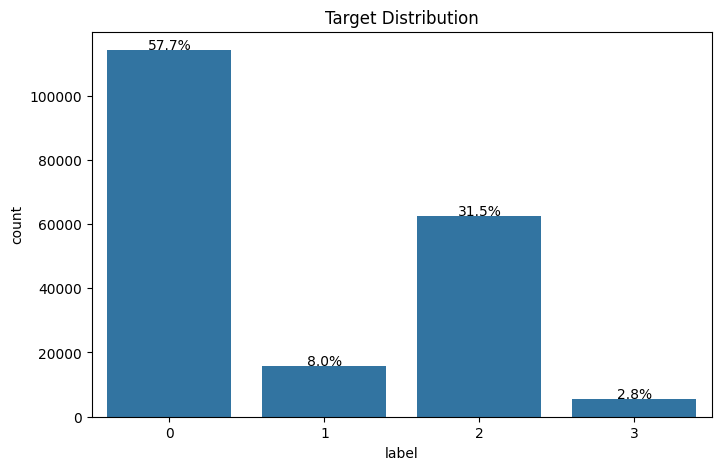

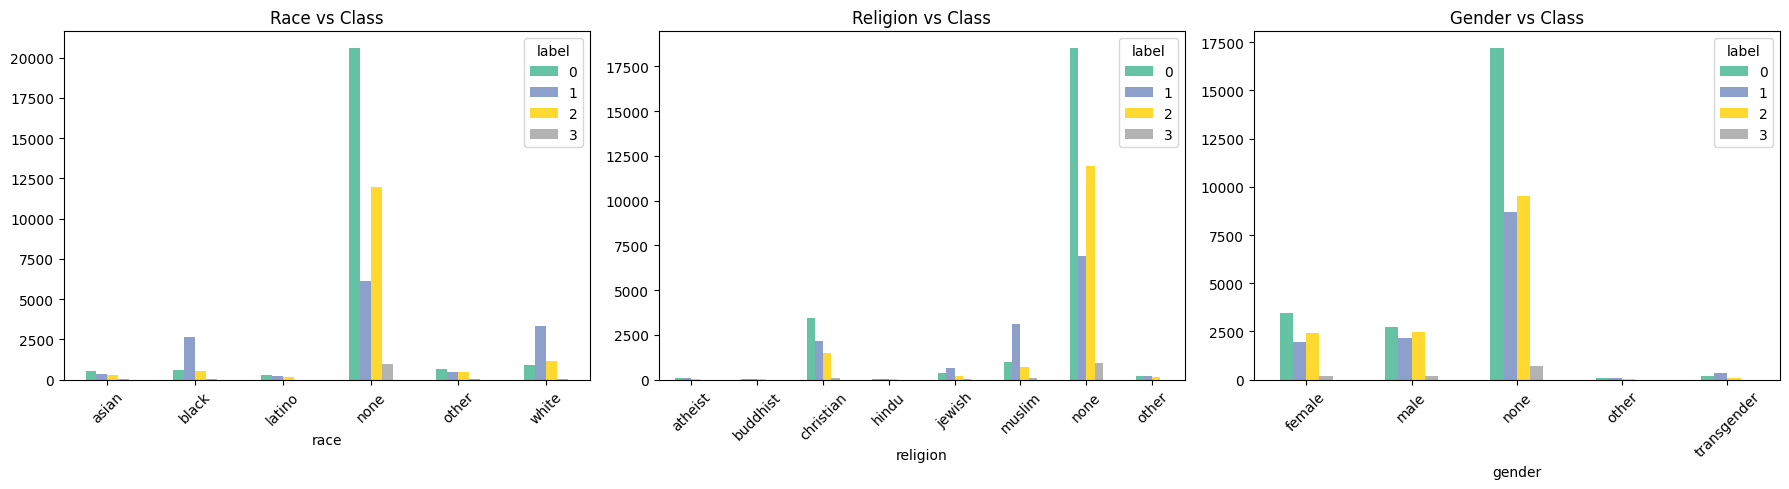

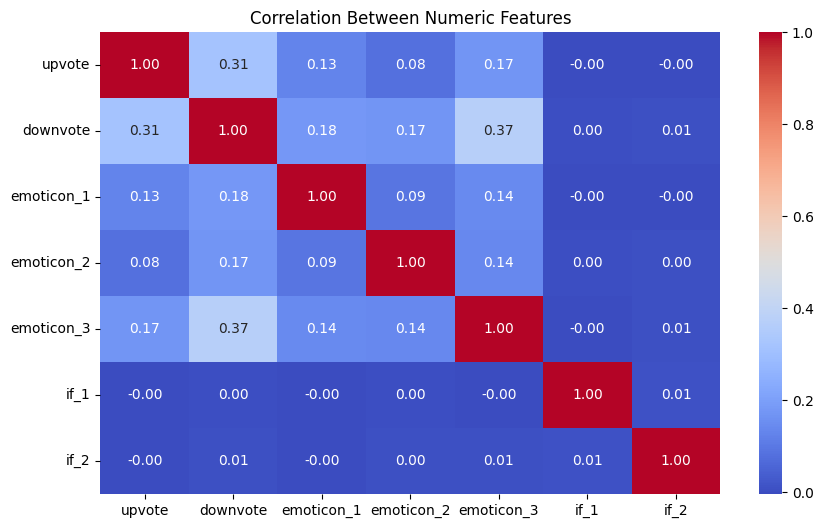


Final numeric features: ['upvote', 'downvote', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'if_1', 'if_2', 'word_count', 'char_count', 'caps_ratio', 'exclamation_count', 'question_count', 'race_known', 'religion_known', 'gender_known', 'demo_known_count']

        word_count  char_count  caps_ratio  exclamation_count
label                                                       
0          52.457     284.734       0.036              0.198
1          58.642     323.948       0.035              0.196
2          56.281     306.115       0.034              0.275
3          35.820     187.617       0.037              0.260




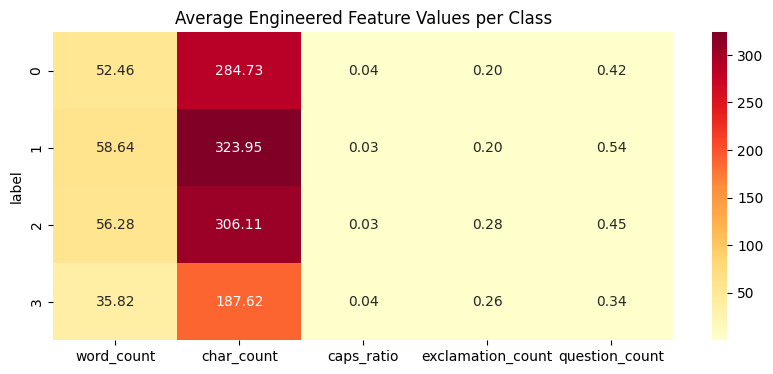

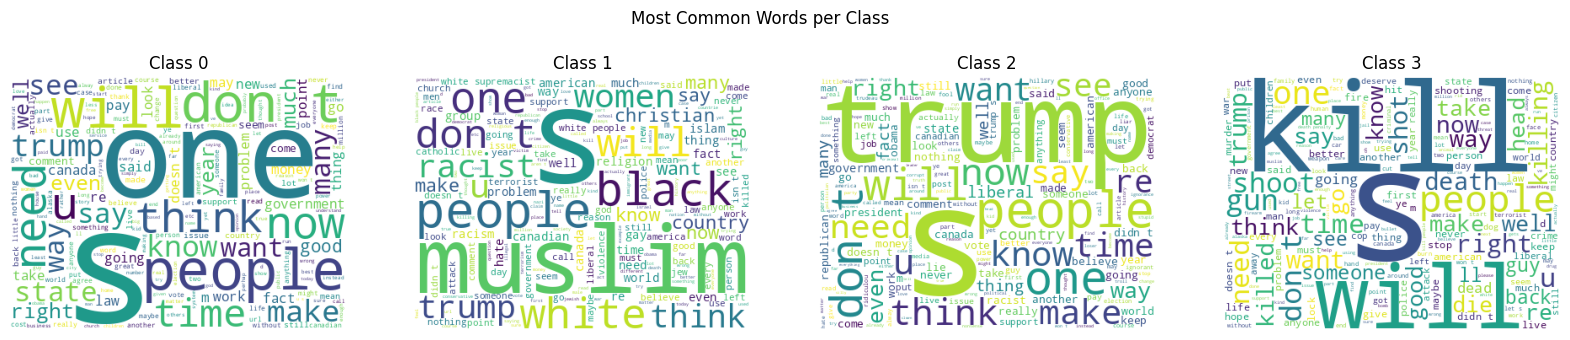

In [3]:
# EDA1 Raw Data
# Statistical analysis
print("\nStatistical Analysis")
print(train_df[['upvote', 'downvote', 'if_1', 'if_2']].describe())

# Missing values check — show count and percentage
print("\nMissing values check")
missing_counts = train_df.isnull().sum()
missing_pct    = (train_df.isnull().sum() / len(train_df) * 100).round(2)
missing_df     = pd.DataFrame({'Missing Count': missing_counts,
                                'Missing %': missing_pct})
missing_df     = missing_df[missing_df['Missing Count'] > 0]
print(missing_df)

# Class Distribution
plt.figure(figsize=(8, 5))
ax = sns.countplot(x=target_col, data=train_df)
total = len(train_df)
for p in ax.patches:
    pct = f'{100 * p.get_height() / total:.1f}%'    # added percentage labels to show imbalance clearly
    ax.annotate(pct, (p.get_x() + p.get_width()/2, p.get_height() + 200), ha='center')
plt.title('Target Distribution')
plt.show()

# Categorical vs Class
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, categorical_cols):
    ct = pd.crosstab(train_df[col], train_df[target_col])
    ct.plot(kind='bar', ax=ax, colormap='Set2')
    ax.set_title(f'{col.capitalize()} vs Class')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Correlation between numeric features
plt.figure(figsize=(10, 6))
sns.heatmap(train_df[numeric_cols_raw].corr(),
            annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Between Numeric Features')
plt.show()

#  Text cleaning
def clean_text_simple(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', ' url ', text) # normalize links
    text = re.sub(r'@\w+', ' user ', text)   # normalize mentions
    text = re.sub(r'[^a-z0-9!?]+', ' ', text)  # keep alphanumeric and spaces
    text = re.sub(r'\s+', ' ', text).strip() # remove extra whitespace
    return text

# cleaning both datasets
train_df['clean_text'] = train_df[text_col].apply(clean_text_simple)
test_df['clean_text']  = test_df[text_col].apply(clean_text_simple)

# Feature Engineering
# Word Count
train_df['word_count'] = train_df['clean_text'].apply(lambda x: len(x.split()))
test_df['word_count']  = test_df['clean_text'].apply(lambda x: len(x.split()))

# Character Count
train_df['char_count'] = train_df['clean_text'].apply(len)
test_df['char_count']  = test_df['clean_text'].apply(len)

# Caps Ratio using original uncleaned comment to check for upcase
def get_caps_ratio(text):
    text = str(text)
    if len(text) == 0: return 0
    return sum(1 for c in text if c.isupper()) / len(text)

train_df['caps_ratio'] = train_df['comment'].apply(get_caps_ratio)
test_df['caps_ratio']  = test_df['comment'].apply(get_caps_ratio)

for df in [train_df, test_df]:
    df['race_known']       = df['race'].notna().astype(int)
    df['religion_known']   = df['religion'].notna().astype(int)
    df['gender_known']     = df['gender'].notna().astype(int)
    df['demo_known_count'] = df['race_known'] + df['religion_known'] + df['gender_known']

# Punctuation Counts using original comment
train_df['exclamation_count'] = train_df['comment'].astype(str).apply(lambda x: x.count('!'))
test_df['exclamation_count']  = test_df['comment'].astype(str).apply(lambda x: x.count('!'))
train_df['question_count']    = train_df['comment'].astype(str).apply(lambda x: x.count('?'))
test_df['question_count']     = test_df['comment'].astype(str).apply(lambda x: x.count('?'))

numeric_cols = numeric_cols_raw + ['word_count', 'char_count', 'caps_ratio',
                                    'exclamation_count', 'question_count',
                                    'race_known', 'religion_known', 
                                    'gender_known', 'demo_known_count']
print("\nFinal numeric features:", numeric_cols)

# EDA2 Engineered Feature Analysis
print("\n",train_df.groupby(target_col)[['word_count','char_count',
      'caps_ratio','exclamation_count']].mean().round(3))
print("\n")

# all engineered features vs class in one clean plot
feat_means = train_df.groupby(target_col)[['word_count','char_count',
             'caps_ratio','exclamation_count','question_count']].mean()
plt.figure(figsize=(10, 4))
sns.heatmap(feat_means, annot=True, fmt='.2f', cmap='YlOrRd')
plt.title('Average Engineered Feature Values per Class')
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for i, ax in enumerate(axes):
    text = ' '.join(train_df[train_df[target_col]==i]['clean_text'])
    wc = WordCloud(width=400, height=300, background_color='white').generate(text)
    ax.imshow(wc)
    ax.axis('off')
    ax.set_title(f'Class {i}')
plt.suptitle('Most Common Words per Class')
plt.show()

In [4]:
# Preprocessing Pipelines
# Pipeline for numeric features handle missing value thenscale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline for text convert cleaned text to TFIDF numerical vectors
text_transformer = FeatureUnion([
    ('word_tfidf', TfidfVectorizer(analyzer='word', stop_words='english', ngram_range=(1, 2), max_features=15000, min_df=2, sublinear_tf=True)),
    ('char_tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 6), max_features=15000, min_df=2, sublinear_tf=True))
])

# Pipeline for categorical demographics
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Pipeline for boolean disability
boolean_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

# Combining to one preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols),
        ('bool', boolean_transformer, boolean_cols),
        ('txt', text_transformer, 'clean_text')
    ])

# Splitting data to evaluate performance
X = train_df.drop(target_col, axis=1)
y = train_df[target_col]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
model_comparison = {}

print(f"Train: {len(X_train)} | Val: {len(X_val)}")
print(f"Class distribution:\n{y_train.value_counts().sort_index()}")

Train: 158400 | Val: 39600
Class distribution:
label
0    91338
1    12735
2    49952
3     4375
Name: count, dtype: int64


In [5]:
# # Baseline model 1 LR
# # HPT using GridSearchCV
# param_grid_lr = {
#     'classifier__C': [0.5, 1.0, 2.0, 3.0], 
#     'classifier__class_weight': ['balanced', {0:1, 1:3, 2:1, 3:8},
#                                               {0:1, 1:4, 2:1, 3:10}]
# }

# model_lr = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('classifier', LogisticRegression(solver='liblinear', max_iter=1000, random_state=42))
# ])

# # cross validates 3 times for every combination
# model_lr_tuned = GridSearchCV(model_lr, param_grid_lr, cv=3, 
#                                scoring='f1_macro', n_jobs=-1)
# # training LR model
# model_lr_tuned.fit(X_train, y_train)
# print(f"Best LR params: {model_lr_tuned.best_params_}")

# # eval on validation set
# val_preds_lr = model_lr_tuned.predict(X_val)
# print(f"LR Validation Accuracy: {accuracy_score(y_val, val_preds_lr):.4f}")
# print(classification_report(y_val, val_preds_lr))

# # final training on full dataset using best params
# model_lr_tuned.best_estimator_.fit(X, y)
# test_preds_lr = model_lr_tuned.best_estimator_.predict(test_df)
# model_comparison["LR"] = {
#     "Accuracy": accuracy_score(y_val, val_preds_lr),
#     "Macro F1": f1_score(y_val, val_preds_lr, average="macro"),
#     "Report": classification_report(y_val, val_preds_lr, output_dict=True)
# }

# # generating submission for LR
# submission_lr = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")
# submission_lr['label'] = test_preds_lr
# submission_lr.to_csv('submission.csv', index=False)
# print("LR csv generated.")

In [6]:
# # Model 2 SGD
# # finds a hyperplane that maximally separates the classes
# model_sgd = Pipeline(steps=[
#     ('preprocessor', preprocessor), 
#     ('classifier', SGDClassifier(
#         loss='modified_huber',
#         class_weight={0:1, 1:3, 2:1, 3:8},  # manual weights to boost minority classes
#         random_state=42, 
#         max_iter=2000,                        # more iterations for convergence
#         l1_ratio=0.15                         # required for elasticnet penalty
#     ))
# ])

# # tuning alpha regularization strength and penalty types
# param_grid_sgd = {
#     'classifier__alpha': [0.0001, 0.001, 0.01],
#     'classifier__penalty': ['l2', 'elasticnet']
# }

# print("Running GridSearchCV for SGD")
# # cross validates 3 times for every combination
# model_sgd_tuned = GridSearchCV(model_sgd, param_grid_sgd, cv=3,
#                                     scoring='f1_macro', n_jobs=-1)
# # training SGD model
# model_sgd_tuned.fit(X_train, y_train)
# print(f"Best SGD Hyperparameters: {model_sgd_tuned.best_params_}")

# # eval on validation set
# val_preds_sgd = model_sgd_tuned.predict(X_val)
# print(f"SGD Validation Accuracy: {accuracy_score(y_val, val_preds_sgd):.4f}")
# print(classification_report(y_val, val_preds_sgd))

# # final training on full dataset
# print("Retraining best SGD model on full dataset")
# best_sgd = model_sgd_tuned.best_estimator_
# best_sgd.fit(X, y)
# test_preds_sgd = best_sgd.predict(test_df)

# model_comparison["SGD"] = {
#     "Accuracy": accuracy_score(y_val, val_preds_sgd),
#     "Macro F1": f1_score(y_val, val_preds_sgd, average="macro"),
#     "Report": classification_report(y_val, val_preds_sgd, output_dict=True)
# }

# # generating submission for SGD
# submission_sgd = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")
# submission_sgd['label'] = test_preds_sgd
# submission_sgd.to_csv('submission.csv', index=False)
# print("SGD csv generated")

In [7]:
# # 3. Stacking Classifier
# # combining LR and SGD as base models with LR as meta learner
# base_models = [
#     ('lr',  LogisticRegression(solver='liblinear', C=1.0, 
#                                 class_weight='balanced', max_iter=1000, random_state=42)),
#     ('sgd', SGDClassifier(loss='modified_huber', alpha=0.0001,
#                           class_weight={0:1, 1:3, 2:1, 3:8}, 
#                           max_iter=2000, l1_ratio=0.15, random_state=42))
# ]

# # stacking classifier base models predict, meta learner learns from their predictions
# stacker_best = StackingClassifier(
#     estimators=base_models,
#     final_estimator=LogisticRegression(solver='liblinear', max_iter=3000, random_state=42), 
#     cv=3,          # 3 fold cross validation for generating meta features
#     passthrough=True,  # passes original features to meta learner as well
#     n_jobs=-1   
# )

# # final pipeline combining preprocessor and stacker
# model_stack_best = Pipeline(steps=[
#     ('preprocessor', preprocessor), 
#     ('stacking', stacker_best)
# ])

# print("Training Stacking Classifier")
# model_stack_best.fit(X_train, y_train)

# # evaluating on validation set
# val_preds_stack_best = model_stack_best.predict(X_val)
# print(f"Stacking Validation Accuracy: {accuracy_score(y_val, val_preds_stack_best):.4f}")
# print(classification_report(y_val, val_preds_stack_best))

# # retraining on full dataset for final submission
# print("Retraining Stacking model on full dataset")
# model_stack_best.fit(X, y)
# test_preds_stack_best = model_stack_best.predict(test_df)

# model_comparison["Stacking"] = {
#     "Accuracy": accuracy_score(y_val, val_preds_stack_best),
#     "Macro F1": f1_score(y_val, val_preds_stack_best, average="macro"),
#     "Report": classification_report(y_val, val_preds_stack_best, output_dict=True)
# }

# # generating submission file
# submission_stack_best = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")
# submission_stack_best['label'] = test_preds_stack_best
# submission_stack_best.to_csv('submission.csv', index=False)
# print("STack csv generated.")

In [8]:
# Model 5 LGB LR Blend
# LGB needs bigger features, LR proven settings
# Blend combines strengths of both models

# LGB preprocessor with bigger features for better performance
lgb_blend_preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols),
    ('bool', boolean_transformer, boolean_cols),
    ('txt', FeatureUnion([
        ('word_tfidf', TfidfVectorizer(
            analyzer='word', stop_words='english',
            ngram_range=(1,3), max_features=30000,
            min_df=2, sublinear_tf=True)),
        ('char_tfidf', TfidfVectorizer(
            analyzer='char_wb', ngram_range=(3,7),
            max_features=50000, min_df=2, sublinear_tf=True))
    ]), 'clean_text')
])

# LR preprocessor with proven settings
lr_blend_preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols),
    ('bool', boolean_transformer, boolean_cols),
    ('txt', FeatureUnion([
        ('word_tfidf', TfidfVectorizer(
            analyzer='word', stop_words='english',
            ngram_range=(1,2), max_features=15000,
            sublinear_tf=True)),
        ('char_tfidf', TfidfVectorizer(
            analyzer='char_wb', ngram_range=(3,6),
            max_features=15000, sublinear_tf=True))
    ]), 'clean_text')
])

# transforming train val and test sets
print("Fitting LGB preprocessor...")
X_lgb_train = csr_matrix(lgb_blend_preprocessor.fit_transform(X_train).astype(np.float32))
X_lgb_val   = csr_matrix(lgb_blend_preprocessor.transform(X_val).astype(np.float32))
X_lgb_test  = csr_matrix(lgb_blend_preprocessor.transform(test_df).astype(np.float32))
gc.collect()

print("Fitting LR preprocessor...")
X_lr_train  = csr_matrix(lr_blend_preprocessor.fit_transform(X_train).astype(np.float32))
X_lr_val    = csr_matrix(lr_blend_preprocessor.transform(X_val).astype(np.float32))
X_lr_test   = csr_matrix(lr_blend_preprocessor.transform(test_df).astype(np.float32))
gc.collect()

# training LGB model
print("Training LGB model")
lgb_blend_model = lgb.LGBMClassifier(
    n_estimators=2000,
    learning_rate=0.020,
    num_leaves=160,
    max_depth=18,
    min_child_samples=15,
    colsample_bytree=0.30,
    subsample=0.85,
    subsample_freq=1,
    reg_alpha=0.6,
    reg_lambda=2.2,
    class_weight={0:1, 1:3.0, 2:1, 3:6.0},
    random_state=42,
    n_jobs=-1,
    force_col_wise=True,
    verbose=-1
)
lgb_blend_model.fit(X_lgb_train, y_train)

# training LR model
print("Training LR model")
lr_blend_model = LogisticRegression(
    C=5.0,
    class_weight='balanced',
    solver='liblinear',
    max_iter=1000,
    random_state=42
)
lr_blend_model.fit(X_lr_train, y_train)

# finding best blend weights on validation set
thresholds    = [0.57, 0.27, 0.34, 0.16]
y_val_arr     = np.array(y_val)
lgb_val_probs = lgb_blend_model.predict_proba(X_lgb_val)
lr_val_probs  = lr_blend_model.predict_proba(X_lr_val)

best_f1    = 0
best_lgb_w = 1.0
best_lr_w  = 0.0

for lgb_w in np.arange(0.0, 1.05, 0.05):
    lr_w    = round(1.0 - lgb_w, 2)
    blended = lgb_w * lgb_val_probs + lr_w * lr_val_probs
    preds   = np.argmax(blended / np.array(thresholds), axis=1)
    f1      = f1_score(y_val_arr, preds, average='macro')
    if f1 > best_f1:
        best_f1    = f1
        best_lgb_w = lgb_w
        best_lr_w  = lr_w

print(f"Best blend weights: LGB={best_lgb_w:.2f} LR={best_lr_w:.2f}")

# eval on validation set
best_blend      = best_lgb_w * lgb_val_probs + best_lr_w * lr_val_probs
val_preds_blend = np.argmax(best_blend / np.array(thresholds), axis=1)
print(f"LGB+LR Blend Validation Accuracy: {accuracy_score(y_val_arr, val_preds_blend):.4f}")
print(classification_report(y_val_arr, val_preds_blend))

model_comparison["LGB+LR Blend"] = {
    "Accuracy": accuracy_score(y_val_arr, val_preds_blend),
    "Macro F1": f1_score(y_val_arr, val_preds_blend, average="macro"),
    "Report":   classification_report(y_val_arr, val_preds_blend, output_dict=True)
}

# generating submission with best blend
print("Generating submission")
test_lgb         = lgb_blend_model.predict_proba(X_lgb_test)
test_lr          = lr_blend_model.predict_proba(X_lr_test)
test_blend       = best_lgb_w * test_lgb + best_lr_w * test_lr
test_preds_blend = np.argmax(test_blend / np.array(thresholds), axis=1)

submission_blend = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")
submission_blend['label'] = test_preds_blend
submission_blend.to_csv('submission.csv', index=False)
print("LGB+LR Blend csv generated.")

Fitting LGB preprocessor...
Fitting LR preprocessor...
Training LGB model
Training LR model


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Best blend weights: LGB=0.80 LR=0.20
LGB+LR Blend Validation Accuracy: 0.9195
              precision    recall  f1-score   support

           0       0.99      0.94      0.96     22835
           1       0.76      0.84      0.79      3183
           2       0.88      0.91      0.89     12488
           3       0.67      0.72      0.69      1094

    accuracy                           0.92     39600
   macro avg       0.82      0.85      0.84     39600
weighted avg       0.92      0.92      0.92     39600

Generating submission


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LGB+LR Blend csv generated.


In [9]:
# # Model Comparison
# print("\n Model Comparison")

# # build comparison dataframe from stored results
# comparison_data = []
# for model_name, metrics in model_comparison.items():
#     report = metrics['Report']
#     comparison_data.append({
#         'Model':      model_name,
#         'Accuracy':   round(metrics['Accuracy'], 4),
#         'Class 0 F1': round(report['0']['f1-score'], 3),
#         'Class 1 F1': round(report['1']['f1-score'], 3),
#         'Class 2 F1': round(report['2']['f1-score'], 3),
#         'Class 3 F1': round(report['3']['f1-score'], 3),
#         'Macro F1':   round(metrics['Macro F1'], 4)
#     })

# results_df = pd.DataFrame(comparison_data)
# print(results_df.to_string(index=False))

# # bar chart comparison
# plt.figure(figsize=(12, 5))
# x     = np.arange(len(results_df))
# width = 0.2

# plt.bar(x - width, results_df['Class 1 F1'], width, label='Class 1 F1')
# plt.bar(x,         results_df['Class 3 F1'], width, label='Class 3 F1')
# plt.bar(x + width, results_df['Macro F1'],   width, label='Macro F1')

# plt.xticks(x, results_df['Model'], rotation=15)
# plt.ylabel('F1 Score')
# plt.title('Model Comparison — F1 Scores')
# plt.legend()
# plt.tight_layout()
# plt.show()

# # macro F1 progression across models
# plt.figure(figsize=(10, 5))
# plt.plot(results_df['Model'], results_df['Macro F1'],
#          marker='o', linewidth=2, markersize=8, color='steelblue')
# for i, v in enumerate(results_df['Macro F1']):
#     plt.text(i, v + 0.001, str(v), ha='center')
# plt.title('Macro F1 Progression Across Models')
# plt.ylabel('Macro F1 Score')
# plt.ylim(0.75, 0.90)
# plt.tight_layout()
# plt.show()


--- Model Comparison ---
              Model  Accuracy  Class 0 F1  Class 1 F1  Class 2 F1  Class 3 F1  Macro F1  Kaggle Score
Logistic Regression    0.8966        0.95        0.76        0.88        0.62      0.80       0.78000
                SGD    0.9000        0.95        0.74        0.87        0.62      0.80       0.79000
  Stacking (LR+SGD)    0.9049        0.95        0.77        0.88        0.65      0.81       0.81000
           LightGBM    0.9200        0.96        0.79        0.89        0.68      0.83       0.83562


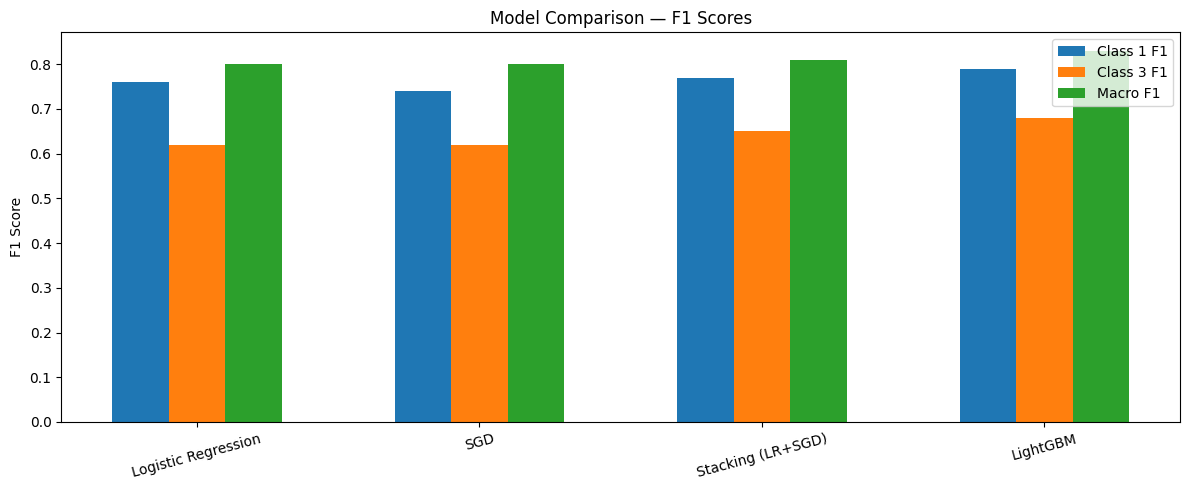

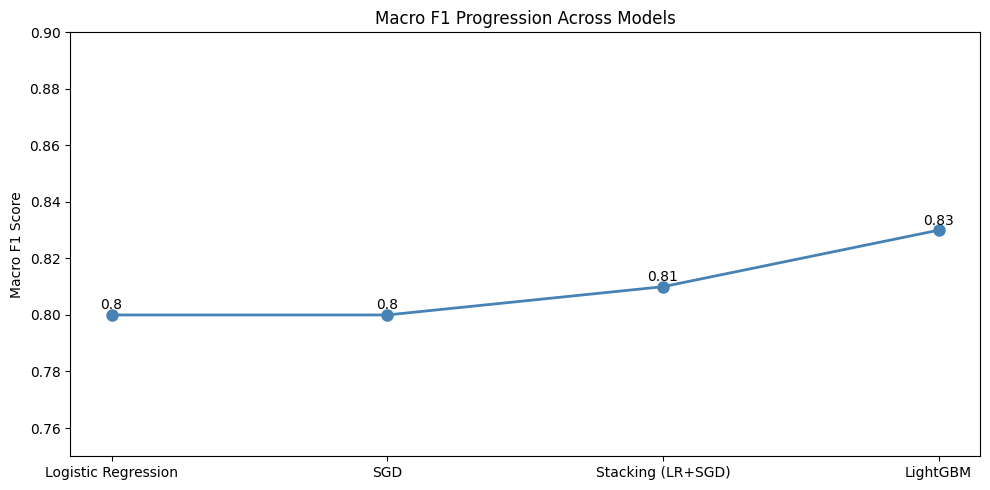

In [10]:
# Model Comparison
from sklearn.metrics import f1_score

# results collected from all model runs above
model_results = {
    'Model':       ['Logistic Regression', 'SGD', 'Stacking (LR+SGD)', 'LightGBM'],
    'Accuracy':    [0.8966, 0.9000, 0.9049, 0.92],
    'Class 0 F1':  [0.95, 0.95, 0.95, 0.96],
    'Class 1 F1':  [0.76, 0.74, 0.77, 0.79],
    'Class 2 F1':  [0.88, 0.87, 0.88, 0.89],
    'Class 3 F1':  [0.62, 0.62, 0.65, 0.68],
    'Macro F1':    [0.80, 0.80, 0.81, 0.83],
    'Kaggle Score':[0.78, 0.79, 0.81,  0.83562]
}

results_df = pd.DataFrame(model_results)
print("\n--- Model Comparison ---")
print(results_df.to_string(index=False))

# bar chart comparison
plt.figure(figsize=(12, 5))
x = np.arange(len(model_results['Model']))
width = 0.2

plt.bar(x - width,   model_results['Class 1 F1'], width, label='Class 1 F1')
plt.bar(x,           model_results['Class 3 F1'], width, label='Class 3 F1')
plt.bar(x + width,   model_results['Macro F1'],   width, label='Macro F1')

plt.xticks(x, model_results['Model'], rotation=15)
plt.ylabel('F1 Score')
plt.title('Model Comparison — F1 Scores')
plt.legend()
plt.tight_layout()
plt.show()

# macro F1 progression
plt.figure(figsize=(10, 5))
plt.plot(model_results['Model'], model_results['Macro F1'], 
         marker='o', linewidth=2, markersize=8, color='steelblue')
for i, v in enumerate(model_results['Macro F1']):
    plt.text(i, v + 0.002, str(v), ha='center')
plt.title('Macro F1 Progression Across Models')
plt.ylabel('Macro F1 Score')
plt.ylim(0.75, 0.90)
plt.tight_layout()
plt.show()

Model Comparison Insights

* LightGBM performed the best with the highest Accuracy at 0.9186 and Macro F1 = 0.83, due to its ability to capture nonlinear relationships and handle complex feature interactions.
* Stacking Classifier improved performance over individual models by combining Logistic Regression and SGD showing the benefit of ensemble learning.
* Logistic Regression and SGD showed similar performance, indicating that linear models are effective but limited in capturing complex patterns.

Key Observations

* The dataset is highly imbalanced, especially for Class 3 (least samples).
* Class 3 has the lowest F1-score (~0.65) across all models, hardest to predict.Tree based models (LightGBM) handle imbalance and feature interactions better than linear models.

Conclusion

* LightGBM is selected as the final model due to its superior performance.
* Macro F1 score was used as a key metric to ensure balanced performance across all classes.
